# Positional Encodings: Teaching Transformers About Order

## What We'll Learn

**The Problem**: Self-attention is **permutation invariant** — it doesn't inherently understand the order of tokens. Shuffling the input sequence produces the same output!

**The Solution**: **Positional encodings** inject position information into token embeddings. This notebook explores:

1. **Why** order matters and self-attention can't see it
2. **Sinusoidal encodings** — the original Transformer approach (wavelength intuition)
3. **Learned embeddings** — GPT-style trainable positions
4. **Absolute vs. Relative** — "this is position 5" vs. "this is 3 after that"
5. **RoPE (Rotary Position Embeddings)** — modern approach for length extrapolation
6. **ALiBi (Attention with Linear Biases)** — no embeddings, just attention bias
7. **Comparison** — train small transformers and see which works best

By the end, you'll understand how transformers perceive sequence order and why modern models favor certain approaches.

## 1. The Position Problem

### Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from typing import Optional, Tuple

from aiml_notebooks import (
    get_device,
    set_seed,
    create_dataset,
    create_dataloaders,
    SinusoidalPositionalEncoding,
    LearnablePositionalEmbedding,
    RelativePositionalEncoding,
    create_causal_mask,
    TrainingHistory,
)

%load_ext autoreload
%autoreload 2

# Set style for better plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

### Random Seed for Reproducibility

Set the random seed to ensure consistent results across runs.

In [2]:
set_seed(42)
device = get_device(prefer_cpu=True)  # Use CPU for stability with transformers
print(f"Using device: {device}")

Using CPU
Note: MPS is available but not used due to compatibility issues
To use MPS with CPU fallback, run: PYTORCH_ENABLE_MPS_FALLBACK=1 jupyter lab
Using device: cpu


### Demonstrating Permutation Invariance

Let's prove that self-attention without positional encoding **cannot distinguish order**.

We'll create a simple self-attention layer and show that shuffling the input produces identical outputs.

In [3]:
class SimpleSelfAttention(nn.Module):
    """Minimal self-attention without positional encoding."""
    
    def __init__(self, d_model: int):
        super().__init__()
        self.d_model = d_model
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch, seq_len, d_model]
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_model)
        attn_weights = F.softmax(scores, dim=-1)
        
        # Weighted sum of values
        output = torch.matmul(attn_weights, V)
        return output

# Create attention layer
attn = SimpleSelfAttention(d_model=64).to(device)
attn.eval()  # No dropout

# Create input sequence [batch=1, seq_len=5, d_model=64]
x_original = torch.randn(1, 5, 64, device=device)

# Get output
with torch.no_grad():
    output_original = attn(x_original)

print("Original sequence shape:", x_original.shape)
print("Original output shape:", output_original.shape)

Original sequence shape: torch.Size([1, 5, 64])
Original output shape: torch.Size([1, 5, 64])


### Shuffling the Sequence

Now shuffle the sequence and pass it through the same attention layer. If attention is permutation invariant, the shuffled outputs should match the original outputs (just in different positions).

In [4]:
# Shuffle the sequence
indices = torch.tensor([3, 1, 4, 0, 2])  # Shuffle order
x_shuffled = x_original[:, indices, :]  # Permute sequence dimension

# Get output for shuffled sequence
with torch.no_grad():
    output_shuffled = attn(x_shuffled)

# Un-shuffle the output to compare
unshuffle_indices = torch.argsort(indices)  # Reverse permutation
output_unshuffled = output_shuffled[:, unshuffle_indices, :]

# Compare
difference = (output_original - output_unshuffled).abs().mean()
print(f"\nMean absolute difference: {difference:.10f}")
print(f"Are they equal? {torch.allclose(output_original, output_unshuffled, atol=1e-6)}")

print("\n" + "="*60)
print("CONCLUSION: Self-attention is PERMUTATION INVARIANT!")
print("Shuffling input produces the same output (in shuffled order).")
print("We MUST add positional information to distinguish order.")
print("="*60)


Mean absolute difference: 0.0000000179
Are they equal? True

CONCLUSION: Self-attention is PERMUTATION INVARIANT!
Shuffling input produces the same output (in shuffled order).
We MUST add positional information to distinguish order.


## 2. Sinusoidal Positional Encodings

### The Original Transformer Approach

The **Attention is All You Need** paper introduced fixed sinusoidal encodings:

$$
\begin{align}
PE_{(pos, 2i)} &= \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \\
PE_{(pos, 2i+1)} &= \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
\end{align}
$$

Where:
- $pos$ = position in sequence (0, 1, 2, ...)
- $i$ = dimension index (0 to $d_{model}/2$)
- Even dimensions use sine, odd use cosine

**Key intuition**: Different dimensions oscillate at different frequencies (wavelengths from $2\pi$ to $10000 \cdot 2\pi$).

### Understanding the Formula: Wavelength Intuition

Let's build the encoding step-by-step to understand the wavelength concept.

In [5]:
def create_sinusoidal_encoding(max_len: int, d_model: int) -> torch.Tensor:
    """
    Create sinusoidal positional encoding from scratch.
    
    Args:
        max_len: Maximum sequence length
        d_model: Model dimensionality (must be even)
    
    Returns:
        Encoding matrix [max_len, d_model]
    """
    # Position indices: [0, 1, 2, ..., max_len-1]
    position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
    
    # Dimension indices: [0, 2, 4, ..., d_model-2]
    dim_indices = torch.arange(0, d_model, 2, dtype=torch.float)  # [d_model/2]
    
    # Compute div_term: 10000^(2i/d_model)
    # We use exp-log trick for numerical stability:
    # 10000^(2i/d) = exp(log(10000) * 2i/d) = exp(2i * log(10000)/d)
    div_term = torch.exp(dim_indices * (-math.log(10000.0) / d_model))  # [d_model/2]
    
    # Compute angles: pos / 10000^(2i/d_model)
    angles = position * div_term  # Broadcasting: [max_len, 1] * [d_model/2] = [max_len, d_model/2]
    
    # Initialize encoding matrix
    pe = torch.zeros(max_len, d_model)
    
    # Apply sine to even dimensions
    pe[:, 0::2] = torch.sin(angles)
    
    # Apply cosine to odd dimensions
    pe[:, 1::2] = torch.cos(angles)
    
    return pe

# Create encoding
pe = create_sinusoidal_encoding(max_len=100, d_model=64)
print(f"Positional encoding shape: {pe.shape}")
print(f"Encoding for position 0: {pe[0, :8]}")
print(f"Encoding for position 10: {pe[10, :8]}")

Positional encoding shape: torch.Size([100, 64])
Encoding for position 0: tensor([0., 1., 0., 1., 0., 1., 0., 1.])
Encoding for position 10: tensor([-0.5440, -0.8391,  0.9376,  0.3476, -0.6129,  0.7901, -0.8798, -0.4754])


### Visualizing the Encoding: Heatmap

Each row represents a position, each column a dimension. Notice the **wave patterns** — different frequencies for different dimensions.

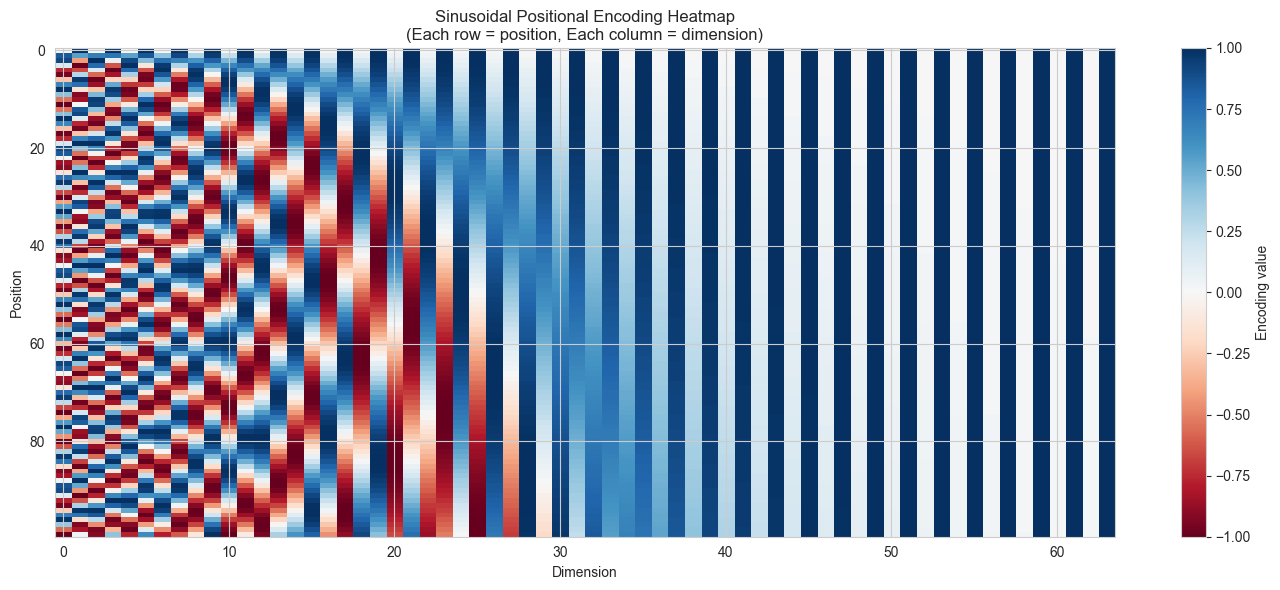


Key observations:
- Early dimensions (left) oscillate RAPIDLY (high frequency)
- Later dimensions (right) oscillate SLOWLY (low frequency)
- This creates a unique 'fingerprint' for each position


In [6]:
# Create encoding for visualization
pe_vis = create_sinusoidal_encoding(max_len=100, d_model=64)

plt.figure(figsize=(14, 6))
plt.imshow(pe_vis.numpy(), cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Encoding value')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding Heatmap\n(Each row = position, Each column = dimension)')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Early dimensions (left) oscillate RAPIDLY (high frequency)")
print("- Later dimensions (right) oscillate SLOWLY (low frequency)")
print("- This creates a unique 'fingerprint' for each position")

### Visualizing Different Frequencies

Plot a few individual dimensions to see the wavelength progression.

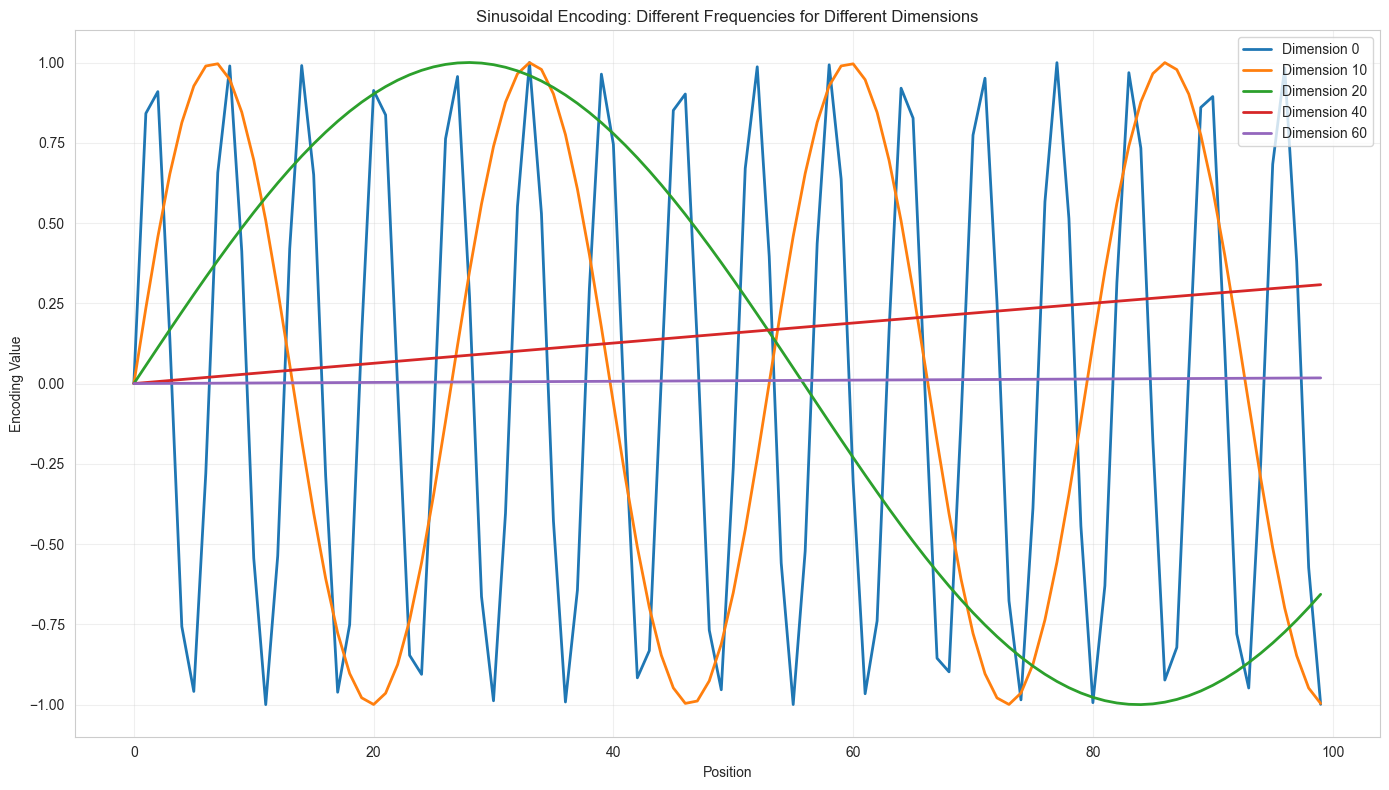


Wavelength progression:
- Dimension 0: Very short wavelength (fast oscillation)
- Dimension 60: Very long wavelength (slow oscillation)
- Together, they encode positions uniquely across many scales


In [7]:
# Select dimensions to visualize
dims_to_plot = [0, 10, 20, 40, 60]  # Different frequencies
positions = np.arange(100)

plt.figure(figsize=(14, 8))
for dim in dims_to_plot:
    plt.plot(positions, pe_vis[:, dim].numpy(), label=f'Dimension {dim}', linewidth=2)

plt.xlabel('Position')
plt.ylabel('Encoding Value')
plt.title('Sinusoidal Encoding: Different Frequencies for Different Dimensions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWavelength progression:")
print("- Dimension 0: Very short wavelength (fast oscillation)")
print("- Dimension 60: Very long wavelength (slow oscillation)")
print("- Together, they encode positions uniquely across many scales")

### Why Sinusoidal Works: Relative Position Property

The encoding has a crucial property: **relative positions can be computed using linear transformations**.

Specifically, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$ because:

$$
\begin{align}
\sin(\alpha + \beta) &= \sin\alpha\cos\beta + \cos\alpha\sin\beta \\
\cos(\alpha + \beta) &= \cos\alpha\cos\beta - \sin\alpha\sin\beta
\end{align}
$$

Let's verify this with dot products between positions.

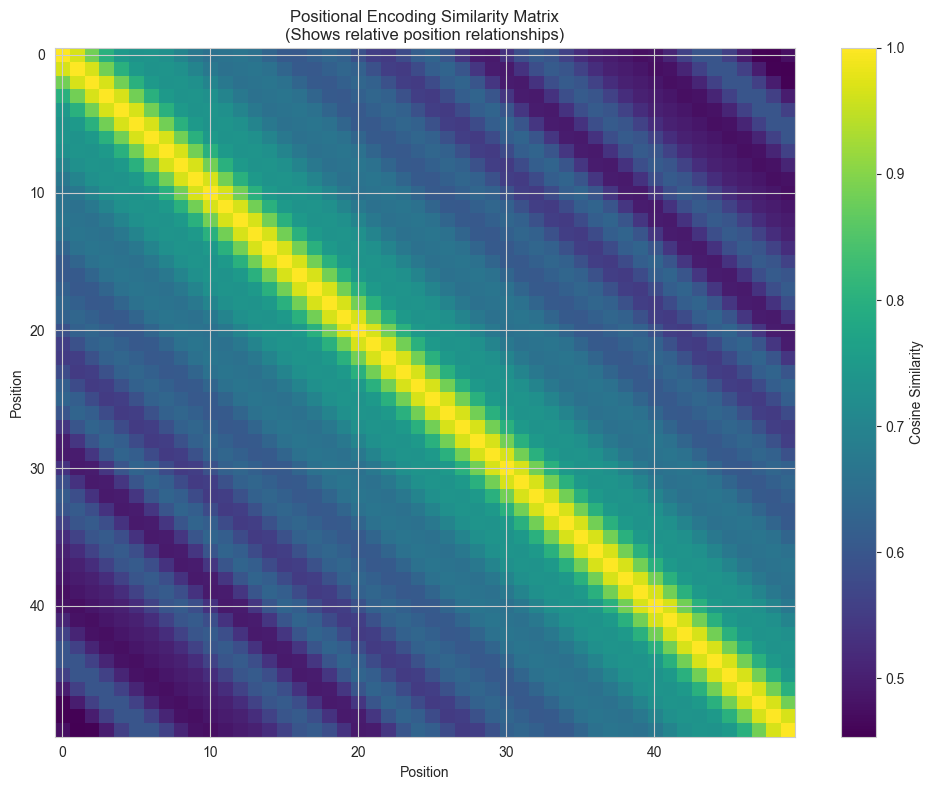


Key insight:
- The diagonal pattern shows that similarity depends on DISTANCE
- Positions that are equally far apart have similar similarity scores
- This means the model can learn 'attend to positions k steps away'


In [8]:
# Compute pairwise dot products between positions
# This reveals the relative position similarity
pe_sample = create_sinusoidal_encoding(max_len=50, d_model=64)

# Normalize encodings for fair comparison
pe_normalized = F.normalize(pe_sample, p=2, dim=1)

# Compute similarity matrix (cosine similarity via dot product)
similarity = torch.matmul(pe_normalized, pe_normalized.t())

plt.figure(figsize=(10, 8))
plt.imshow(similarity.numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Positional Encoding Similarity Matrix\n(Shows relative position relationships)')
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("- The diagonal pattern shows that similarity depends on DISTANCE")
print("- Positions that are equally far apart have similar similarity scores")
print("- This means the model can learn 'attend to positions k steps away'")

### Using the Shared Library Implementation

Now let's use the production-ready implementation from `aiml_notebooks`.

In [9]:
# Create sinusoidal encoding module
pos_encoder = SinusoidalPositionalEncoding(d_model=64, max_len=100, dropout=0.0)
pos_encoder = pos_encoder.to(device)

# Test with sample input
x = torch.randn(2, 20, 64, device=device)  # [batch, seq_len, d_model]
x_with_pos = pos_encoder(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {x_with_pos.shape}")
print(f"\nPositional encoding added successfully!")

Input shape: torch.Size([2, 20, 64])
Output shape: torch.Size([2, 20, 64])

Positional encoding added successfully!


## 3. Learned Positional Embeddings

### The GPT Approach

Instead of fixed sinusoidal patterns, we can **learn** position embeddings during training, just like word embeddings.

**Advantages**:
- Task-specific: embeddings adapt to the specific patterns in your data
- Simple: just an embedding table lookup

**Disadvantages**:
- Fixed maximum length: can't extrapolate to longer sequences
- Requires more parameters: $O(\text{max_len} \times d_{model})$

### Implementation

Learned embeddings are simply an `nn.Embedding` layer indexed by position.

In [10]:
# Create learnable position embeddings
max_len = 100
d_model = 64

learned_pos_emb = LearnablePositionalEmbedding(max_len=max_len, d_model=d_model, dropout=0.0)
learned_pos_emb = learned_pos_emb.to(device)

# Test
x = torch.randn(2, 20, 64, device=device)
x_with_learned = learned_pos_emb(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {x_with_learned.shape}")
print(f"\nNumber of parameters: {sum(p.numel() for p in learned_pos_emb.parameters())}")
print(f"(Compare to sinusoidal: 0 parameters — it's fixed!)")

Input shape: torch.Size([2, 20, 64])
Output shape: torch.Size([2, 20, 64])

Number of parameters: 6400
(Compare to sinusoidal: 0 parameters — it's fixed!)


### Visualizing Learned Embeddings (Before Training)

Initially, learned embeddings are **random**. After training, they develop structure.

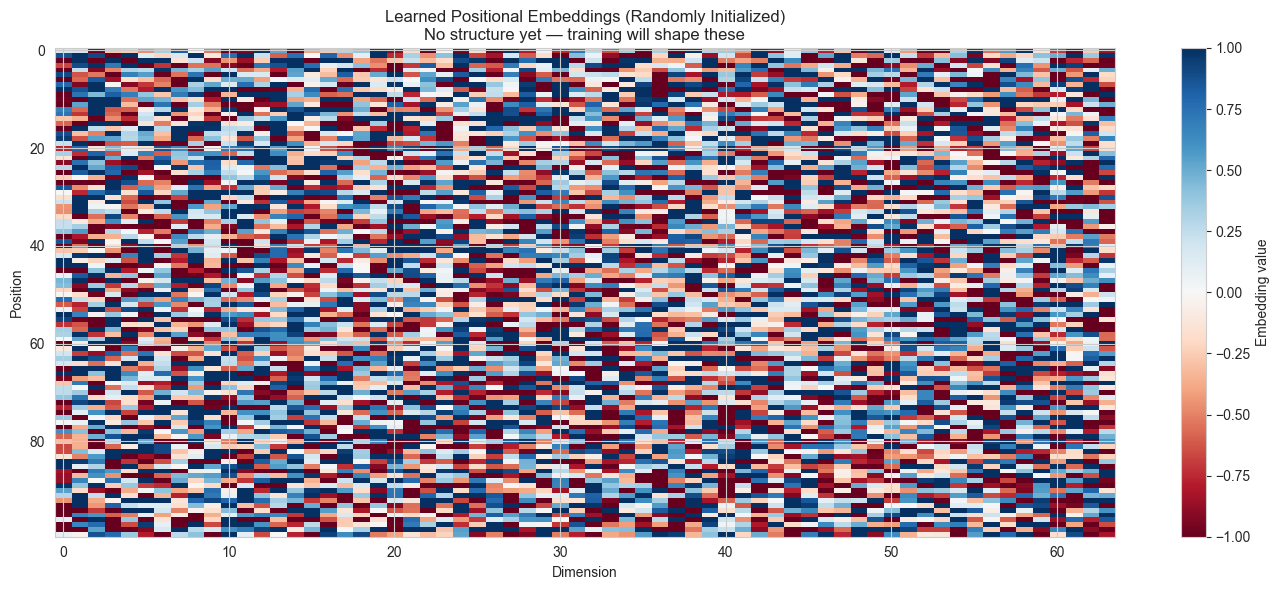


Before training: random noise
After training: will develop patterns specific to the task


In [11]:
# Extract the embedding weights
learned_weights = learned_pos_emb.pos_embedding.weight.detach().cpu()  # [max_len, d_model]

plt.figure(figsize=(14, 6))
plt.imshow(learned_weights.numpy(), cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Embedding value')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.title('Learned Positional Embeddings (Randomly Initialized)\nNo structure yet — training will shape these')
plt.tight_layout()
plt.show()

print("\nBefore training: random noise")
print("After training: will develop patterns specific to the task")

## 4. Absolute vs. Relative Positional Encodings

### Two Philosophies

**Absolute encodings** (sinusoidal, learned):
- Encode each position independently: "this is position 5"
- Added to token embeddings before attention
- Model must learn to compute relative distances

**Relative encodings**:
- Encode distances between positions: "this is 3 positions after that"
- Added directly to attention scores as a bias
- More natural for sequence modeling (distances matter more than absolute positions)
- Better generalization to longer sequences

### T5-Style Relative Position Bias

The T5 model uses **relative position bias**: learned embeddings based on the distance between query and key positions.

Let's use our shared library's implementation.

In [12]:
# Create relative positional encoding
rel_pos_enc = RelativePositionalEncoding(
    d_model=64,
    max_relative_position=32,  # Maximum distance to encode
    num_heads=8
).to(device)

# Generate bias for a sequence
seq_len = 20
bias = rel_pos_enc(seq_len_q=seq_len, seq_len_k=seq_len, device=device)

print(f"Relative position bias shape: {bias.shape}")  # [num_heads, seq_len, seq_len]
print(f"This bias is added to attention scores before softmax")

Relative position bias shape: torch.Size([8, 20, 20])
This bias is added to attention scores before softmax


### Visualizing Relative Position Bias

The bias matrix shows how attention scores are adjusted based on relative distance.

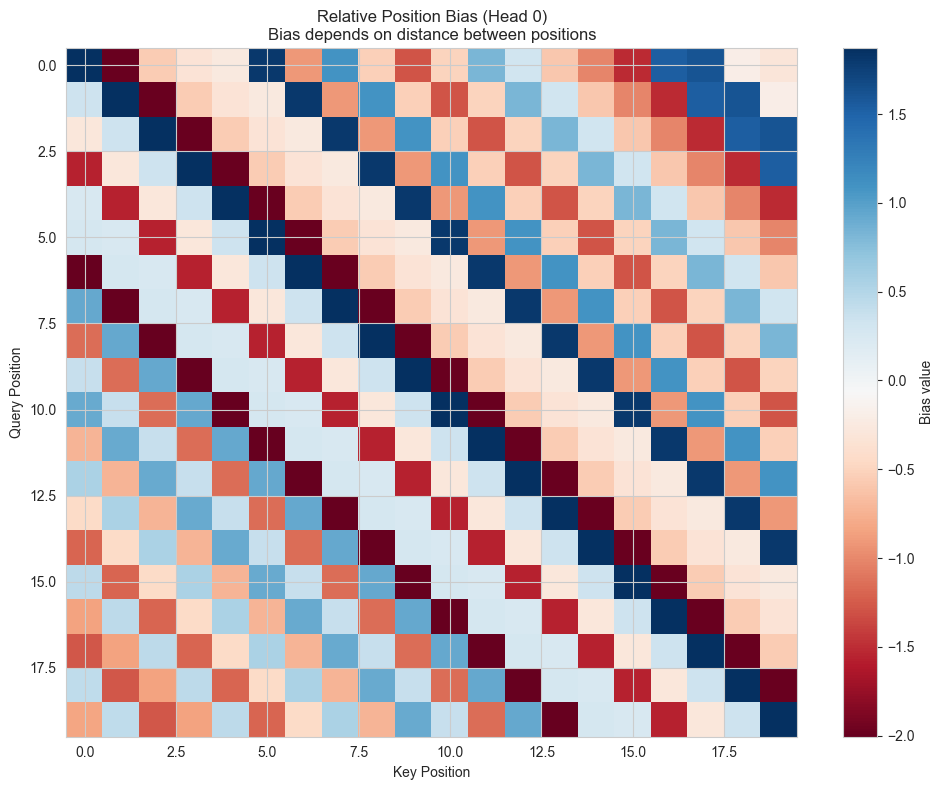


Key insight:
- Diagonal pattern shows that bias depends on relative distance
- Position 0 attending to position 5 gets the same bias as position 10 attending to 15
- This encourages translation invariance in attention patterns


In [13]:
# Visualize bias for first attention head
bias_head_0 = bias[0].detach().cpu().numpy()  # [seq_len, seq_len]

plt.figure(figsize=(10, 8))
plt.imshow(bias_head_0, cmap='RdBu', aspect='auto')
plt.colorbar(label='Bias value')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Relative Position Bias (Head 0)\nBias depends on distance between positions')
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("- Diagonal pattern shows that bias depends on relative distance")
print("- Position 0 attending to position 5 gets the same bias as position 10 attending to 15")
print("- This encourages translation invariance in attention patterns")

## 5. Rotary Position Embeddings (RoPE)

### The Modern Approach

**RoPE** (used in LLaMA, GPT-NeoX, PaLM) is a clever approach that:
1. Rotates query and key vectors by an angle proportional to their position
2. Encodes relative position through the angle between rotations
3. Enables **length extrapolation** (generalize to longer sequences than seen in training)

**Key idea**: In 2D, rotating a vector by angle $\theta$ then dotting with another vector rotated by $\phi$ gives the same result as dotting the original vectors then applying rotation by $(\theta - \phi)$.

For position $m$, we rotate dimensions $(2i, 2i+1)$ by angle $m \cdot \theta_i$, where:

$$\theta_i = 10000^{-2i/d}$$

### RoPE Implementation from Scratch

We'll implement RoPE step by step to build intuition.

In [14]:
class RotaryPositionEmbedding(nn.Module):
    """
    Rotary Position Embedding (RoPE).
    
    Applies rotation to query and key vectors based on their position.
    The rotation angle is proportional to position, enabling relative
    position encoding through rotation differences.
    """
    
    def __init__(self, dim: int, max_len: int = 2048, base: float = 10000.0):
        """
        Args:
            dim: Dimension of embeddings (should be even)
            max_len: Maximum sequence length
            base: Base for frequency calculation (10000 in original paper)
        """
        super().__init__()
        self.dim = dim
        self.max_len = max_len
        self.base = base
        
        # Precompute inverse frequencies
        inv_freq = 1.0 / (
            base ** (torch.arange(0, dim, 2, dtype=torch.float) / dim)
        )
        self.register_buffer('inv_freq', inv_freq)
        
        # Precompute positional embeddings
        self._build_cache(max_len)
    
    def _build_cache(self, max_len: int):
        """Precompute rotation matrices for all positions."""
        # Position indices [0, 1, 2, ..., max_len-1]
        positions = torch.arange(max_len, dtype=torch.float)
        
        # Compute angles: position * inv_freq
        # [max_len, 1] * [dim/2] = [max_len, dim/2]
        angles = torch.einsum('i,j->ij', positions, self.inv_freq)
        
        # Create cos and sin caches [max_len, dim/2]
        self.register_buffer('cos_cache', angles.cos())
        self.register_buffer('sin_cache', angles.sin())
    
    def rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        """
        Rotate half the dimensions.
        
        Splits x into pairs and applies: [x1, x2] -> [-x2, x1]
        This is the 2D rotation operation.
        """
        x1, x2 = x[..., ::2], x[..., 1::2]  # Split into even and odd dimensions
        # Interleave: [-x2[0], x1[0], -x2[1], x1[1], ...]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)
    
    def forward(self, q: torch.Tensor, k: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Apply rotary position embedding to queries and keys.
        
        Args:
            q: Query tensor [batch, seq_len, num_heads, head_dim]
            k: Key tensor [batch, seq_len, num_heads, head_dim]
        
        Returns:
            (q_rotated, k_rotated): Position-encoded queries and keys
        """
        seq_len = q.shape[1]
        
        # Get cos and sin for this sequence length
        cos = self.cos_cache[:seq_len].unsqueeze(0).unsqueeze(2)  # [1, seq_len, 1, dim/2]
        sin = self.sin_cache[:seq_len].unsqueeze(0).unsqueeze(2)  # [1, seq_len, 1, dim/2]
        
        # Repeat for all dimensions (each pair shares same rotation)
        cos = cos.repeat_interleave(2, dim=-1)  # [1, seq_len, 1, dim]
        sin = sin.repeat_interleave(2, dim=-1)  # [1, seq_len, 1, dim]
        
        # Apply rotation: x * cos + rotate_half(x) * sin
        # This is the 2D rotation formula
        q_rotated = q * cos + self.rotate_half(q) * sin
        k_rotated = k * cos + self.rotate_half(k) * sin
        
        return q_rotated, k_rotated

# Create RoPE module
rope = RotaryPositionEmbedding(dim=64, max_len=100).to(device)

# Test with sample queries and keys
batch_size, seq_len, num_heads, head_dim = 2, 20, 8, 64
q = torch.randn(batch_size, seq_len, num_heads, head_dim, device=device)
k = torch.randn(batch_size, seq_len, num_heads, head_dim, device=device)

q_rope, k_rope = rope(q, k)

print(f"Query shape: {q.shape}")
print(f"Query with RoPE shape: {q_rope.shape}")
print(f"\nRoPE applied successfully!")

Query shape: torch.Size([2, 20, 8, 64])
Query with RoPE shape: torch.Size([2, 20, 8, 64])

RoPE applied successfully!


### Visualizing RoPE: Rotation Angles

Let's visualize the rotation angles for different positions and dimensions.

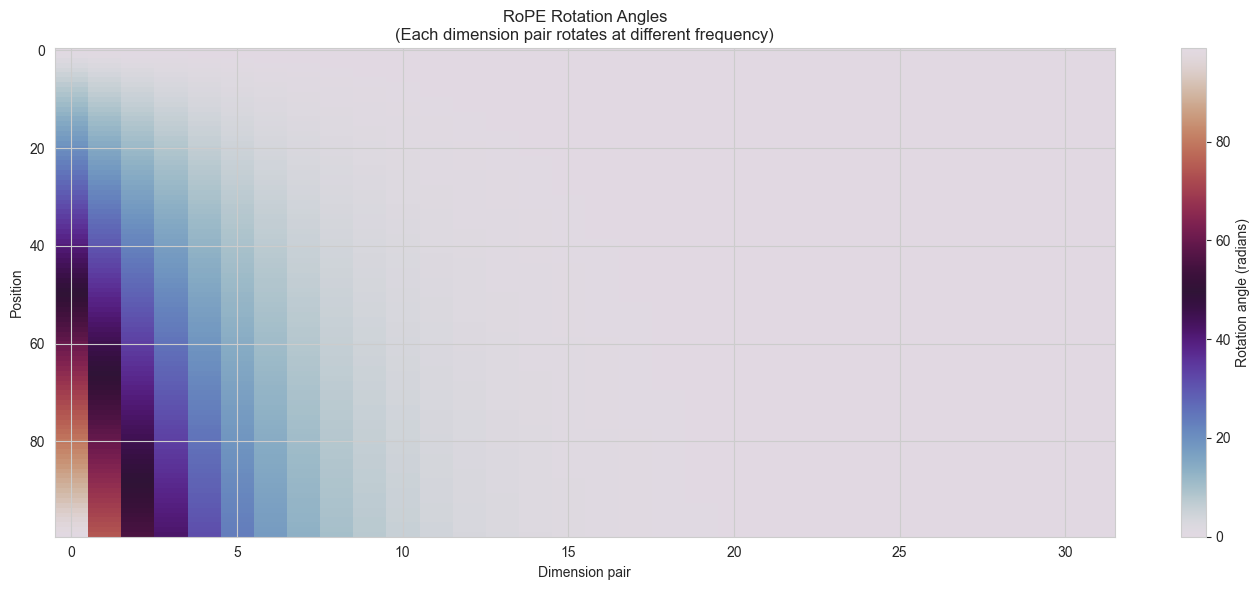


Key insight:
- Early dimension pairs rotate FAST (high frequency)
- Later dimension pairs rotate SLOW (low frequency)
- Similar to sinusoidal encoding, but applied as rotation!


In [15]:
# Extract angles (in the cache, we store cos/sin, but let's recompute for visualization)
positions = torch.arange(100, dtype=torch.float)
angles = torch.einsum('i,j->ij', positions, rope.inv_freq)  # [max_len, dim/2]

# Visualize as heatmap
plt.figure(figsize=(14, 6))
plt.imshow(angles.numpy(), cmap='twilight', aspect='auto')
plt.colorbar(label='Rotation angle (radians)')
plt.xlabel('Dimension pair')
plt.ylabel('Position')
plt.title('RoPE Rotation Angles\n(Each dimension pair rotates at different frequency)')
plt.tight_layout()
plt.show()

print("\nKey insight:")
print("- Early dimension pairs rotate FAST (high frequency)")
print("- Later dimension pairs rotate SLOW (low frequency)")
print("- Similar to sinusoidal encoding, but applied as rotation!")

### Why RoPE Enables Length Extrapolation

RoPE encodes **relative position through rotation differences**. The dot product between:
- Query at position $m$ (rotated by angle $m \theta$)
- Key at position $n$ (rotated by angle $n \theta$)

Depends only on the relative angle $(m - n) \theta$.

This means the model can generalize to distances it hasn't seen during training!

In [16]:
# Demonstrate relative position property
# Create two query-key pairs with the same relative distance

# Pair 1: positions (5, 10) — distance = 5
q1 = torch.randn(1, 1, 1, 64, device=device)  # Single query
k1 = torch.randn(1, 1, 1, 64, device=device)  # Single key

# Manually apply rotation for position 5 and 10
pos_q1 = 5
pos_k1 = 10
cos_q1 = rope.cos_cache[pos_q1].repeat_interleave(2)
sin_q1 = rope.sin_cache[pos_q1].repeat_interleave(2)
cos_k1 = rope.cos_cache[pos_k1].repeat_interleave(2)
sin_k1 = rope.sin_cache[pos_k1].repeat_interleave(2)

q1_rope = q1 * cos_q1 + rope.rotate_half(q1) * sin_q1
k1_rope = k1 * cos_k1 + rope.rotate_half(k1) * sin_k1

# Pair 2: positions (20, 25) — same distance = 5
q2 = q1.clone()  # Same vector
k2 = k1.clone()  # Same vector

pos_q2 = 20
pos_k2 = 25
cos_q2 = rope.cos_cache[pos_q2].repeat_interleave(2)
sin_q2 = rope.sin_cache[pos_q2].repeat_interleave(2)
cos_k2 = rope.cos_cache[pos_k2].repeat_interleave(2)
sin_k2 = rope.sin_cache[pos_k2].repeat_interleave(2)

q2_rope = q2 * cos_q2 + rope.rotate_half(q2) * sin_q2
k2_rope = k2 * cos_k2 + rope.rotate_half(k2) * sin_k2

# Compute dot products
dot1 = (q1_rope * k1_rope).sum()
dot2 = (q2_rope * k2_rope).sum()

print(f"Dot product for positions (5, 10): {dot1:.6f}")
print(f"Dot product for positions (20, 25): {dot2:.6f}")
print(f"\nAre they equal? {torch.allclose(dot1, dot2, atol=1e-5)}")
print("\nConclusion: Same relative distance = same attention pattern!")
print("This enables generalization to longer sequences.")

Dot product for positions (5, 10): -2.466499
Dot product for positions (20, 25): -2.466499

Are they equal? True

Conclusion: Same relative distance = same attention pattern!
This enables generalization to longer sequences.


## 6. ALiBi: Attention with Linear Biases

### The Simplest Approach

**ALiBi** (Attention with Linear Biases) takes a radical approach:
- **No positional embeddings** are added to tokens
- Instead, add a **linear bias** directly to attention scores based on distance
- The bias is $-m \cdot |i - j|$ where $m$ is a head-specific slope

**Advantages**:
- Extremely simple
- Excellent length extrapolation
- No additional parameters
- Linear memory in sequence length

**How it works**: For each attention head $h$, define slope $m_h$. When query at position $i$ attends to key at position $j$:

$$\text{attn\_score}_{ij} = Q_i \cdot K_j - m_h \cdot |i - j|$$

The negative bias penalizes distant positions (attend more to nearby tokens).

### ALiBi Implementation

Let's implement ALiBi from scratch.

In [17]:
class ALiBiPositionalBias(nn.Module):
    """
    Attention with Linear Biases (ALiBi).
    
    Adds a linear penalty to attention scores based on distance.
    No positional embeddings are added to inputs.
    """
    
    def __init__(self, num_heads: int):
        """
        Args:
            num_heads: Number of attention heads
        """
        super().__init__()
        self.num_heads = num_heads
        
        # Compute slopes for each head
        # Original paper uses: 2^(-8/n), 2^(-16/n), ...
        # For n=8: [0.5, 0.25, 0.125, ...]
        slopes = self._get_slopes(num_heads)
        self.register_buffer('slopes', slopes)
    
    def _get_slopes(self, num_heads: int) -> torch.Tensor:
        """
        Compute geometric sequence of slopes.
        
        For 8 heads: [2^(-1), 2^(-2), 2^(-3), ..., 2^(-8)]
                   = [0.5, 0.25, 0.125, 0.0625, ...]
        """
        def get_slopes_power_of_2(n):
            start = 2 ** (-2 ** -(math.log2(n) - 3))
            ratio = start
            return [start * (ratio ** i) for i in range(n)]
        
        # Handle non-power-of-2 heads
        if math.log2(num_heads).is_integer():
            slopes = get_slopes_power_of_2(num_heads)
        else:
            # Use closest power of 2
            closest_power_of_2 = 2 ** math.floor(math.log2(num_heads))
            slopes = get_slopes_power_of_2(closest_power_of_2)
            # Interpolate for remaining heads
            extra_slopes = get_slopes_power_of_2(2 * closest_power_of_2)
            slopes = slopes + extra_slopes[::2][:num_heads - closest_power_of_2]
        
        return torch.tensor(slopes, dtype=torch.float)
    
    def forward(self, seq_len: int, device: torch.device) -> torch.Tensor:
        """
        Compute ALiBi bias matrix.
        
        Args:
            seq_len: Sequence length
            device: Device for tensor creation
        
        Returns:
            Bias matrix [num_heads, seq_len, seq_len]
        """
        # Create position indices
        positions = torch.arange(seq_len, device=device)
        
        # Compute pairwise distances |i - j|
        # [seq_len, 1] - [1, seq_len] = [seq_len, seq_len]
        distances = (positions.unsqueeze(0) - positions.unsqueeze(1)).abs()
        
        # Apply slopes: [num_heads, 1, 1] * [1, seq_len, seq_len]
        slopes = self.slopes.to(device).view(self.num_heads, 1, 1)
        bias = -slopes * distances.unsqueeze(0)  # Negative because we penalize distance
        
        return bias

# Create ALiBi module
alibi = ALiBiPositionalBias(num_heads=8).to(device)

# Generate bias
seq_len = 20
bias = alibi(seq_len, device)

print(f"ALiBi bias shape: {bias.shape}")  # [num_heads, seq_len, seq_len]
print(f"Slopes: {alibi.slopes}")
print(f"\nThis bias is added to attention scores before softmax")

ALiBi bias shape: torch.Size([8, 20, 20])
Slopes: tensor([0.5000, 0.2500, 0.1250, 0.0625, 0.0312, 0.0156, 0.0078, 0.0039])

This bias is added to attention scores before softmax


### Visualizing ALiBi Bias

The bias matrix shows linear penalties based on distance.

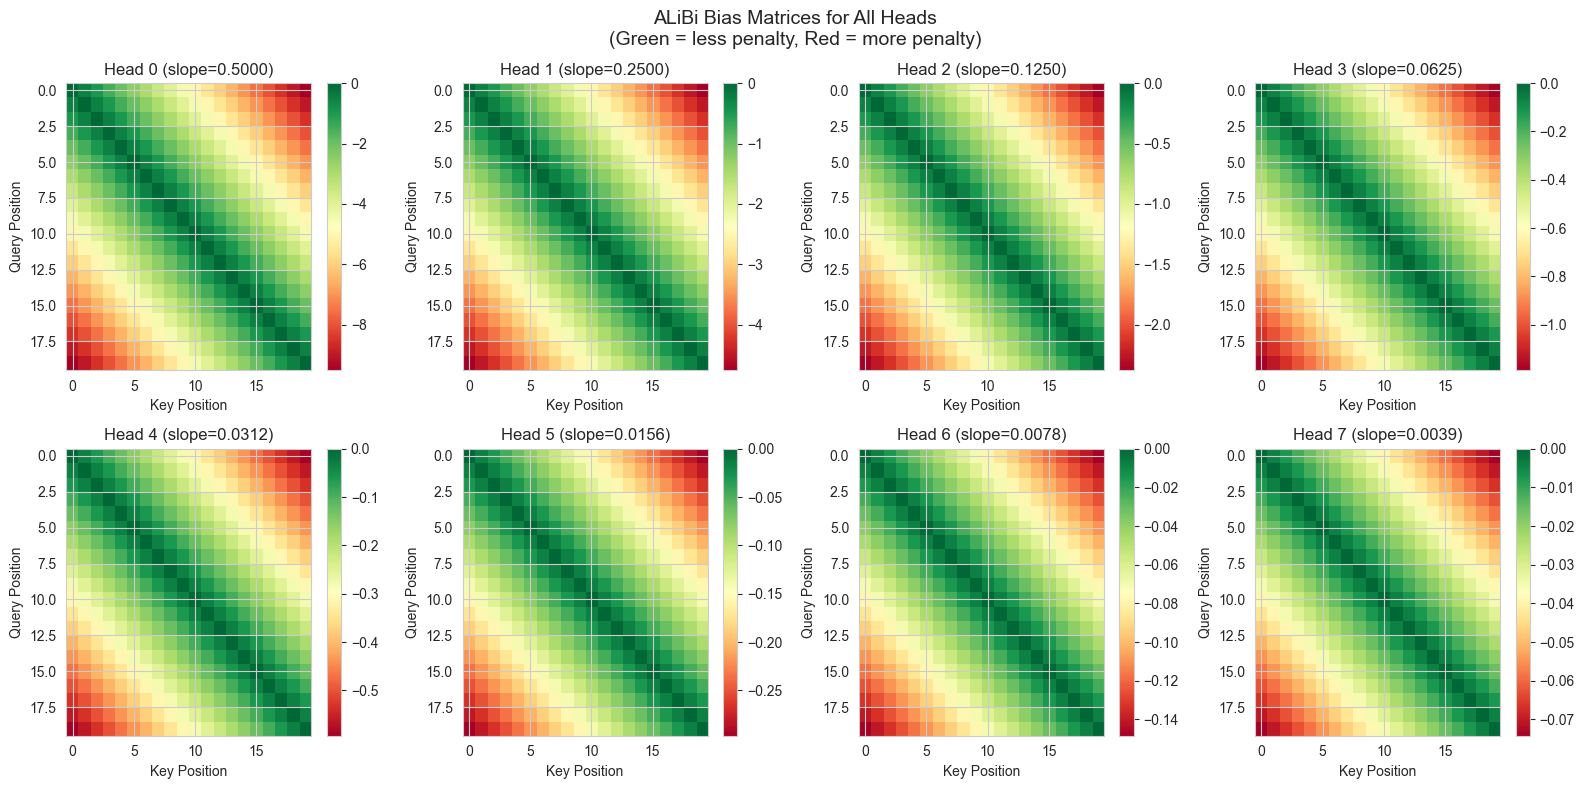


Key observations:
- Diagonal is zero (no penalty for attending to same position)
- Bias increases linearly with distance
- Different heads have different slopes (diversity in attention patterns)
- Head 0 (largest slope) penalizes distance most strongly


In [18]:
# Visualize bias for different heads
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head in range(8):
    ax = axes[head]
    bias_head = bias[head].cpu().numpy()
    
    im = ax.imshow(bias_head, cmap='RdYlGn', aspect='auto')
    ax.set_title(f'Head {head} (slope={alibi.slopes[head]:.4f})')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    plt.colorbar(im, ax=ax)

plt.suptitle('ALiBi Bias Matrices for All Heads\n(Green = less penalty, Red = more penalty)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Diagonal is zero (no penalty for attending to same position)")
print("- Bias increases linearly with distance")
print("- Different heads have different slopes (diversity in attention patterns)")
print("- Head 0 (largest slope) penalizes distance most strongly")

### ALiBi vs. Other Methods: Distance Penalty

Compare how different methods handle position information.

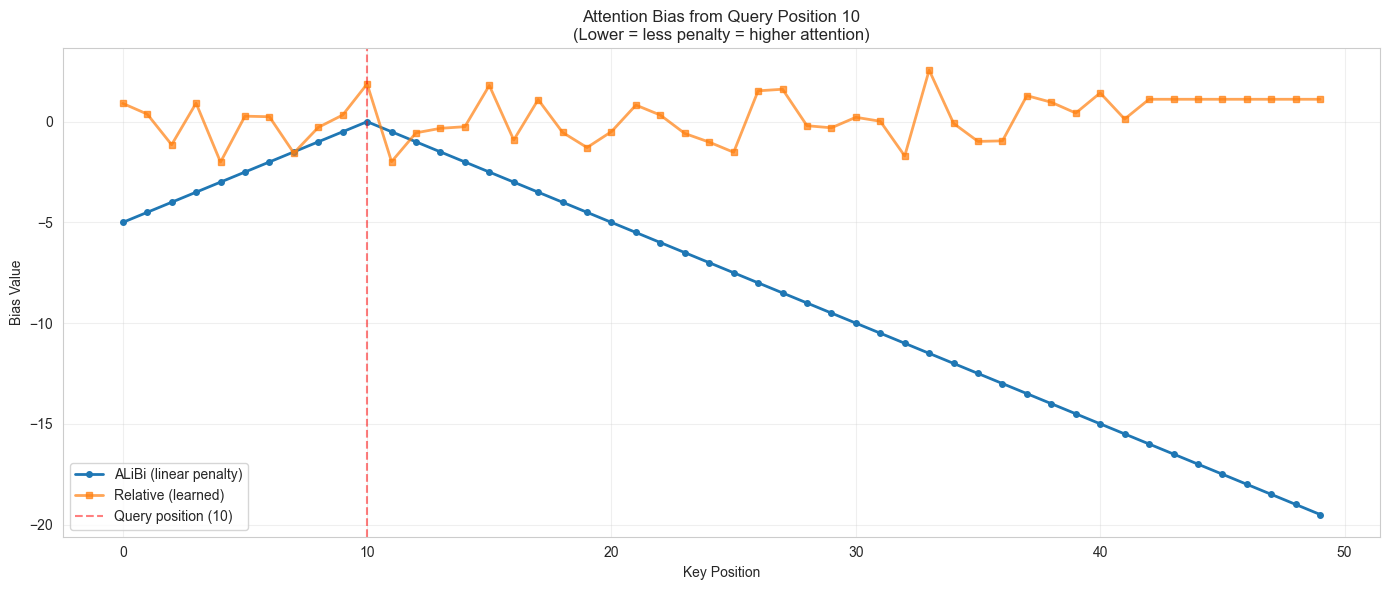


ALiBi: Simple linear penalty
Relative: Complex learned pattern (before training, it's random)


In [19]:
# For a single query position, plot bias across all key positions
query_pos = 10
seq_len = 50

# ALiBi bias
alibi_bias_full = alibi(seq_len, device)
alibi_bias_query = alibi_bias_full[0, query_pos, :].detach().cpu().numpy()  # Head 0

# Relative position bias (for comparison)
rel_pos_bias_full = rel_pos_enc(seq_len_q=seq_len, seq_len_k=seq_len, device=device)
rel_pos_bias_query = rel_pos_bias_full[0, query_pos, :].detach().cpu().numpy()  # Head 0

# Plot
plt.figure(figsize=(14, 6))
positions = np.arange(seq_len)

plt.plot(positions, alibi_bias_query, label='ALiBi (linear penalty)', linewidth=2, marker='o', markersize=4)
plt.plot(positions, rel_pos_bias_query, label='Relative (learned)', linewidth=2, marker='s', markersize=4, alpha=0.7)

plt.axvline(query_pos, color='red', linestyle='--', alpha=0.5, label=f'Query position ({query_pos})')
plt.xlabel('Key Position')
plt.ylabel('Bias Value')
plt.title(f'Attention Bias from Query Position {query_pos}\n(Lower = less penalty = higher attention)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nALiBi: Simple linear penalty")
print("Relative: Complex learned pattern (before training, it's random)")

## 7. Training Comparison: Which Encoding Works Best?

### Setup: Simple Transformer for Character-Level Language Modeling

We'll train minimal transformers with different positional encodings and compare:
1. Training loss
2. Validation loss
3. Length extrapolation ability

First, let's create a simple transformer decoder.

In [20]:
class SimpleTransformerDecoder(nn.Module):
    """
    Minimal transformer decoder for language modeling.
    
    Supports different positional encoding strategies.
    """
    
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        num_heads: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        max_len: int = 100,
        pos_encoding: str = 'sinusoidal',
    ):
        super().__init__()
        
        self.d_model = d_model
        self.pos_encoding_type = pos_encoding
        
        # Token embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Positional encoding (different strategies)
        if pos_encoding == 'sinusoidal':
            self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_len, dropout)
        elif pos_encoding == 'learned':
            self.pos_encoding = LearnablePositionalEmbedding(max_len, d_model, dropout)
        elif pos_encoding == 'rope':
            self.pos_encoding = RotaryPositionEmbedding(d_model, max_len)
        elif pos_encoding == 'alibi':
            self.pos_encoding = ALiBiPositionalBias(num_heads)
        else:
            raise ValueError(f"Unknown pos_encoding: {pos_encoding}")
        
        # Transformer layers
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        # Output projection
        self.output_projection = nn.Linear(d_model, vocab_size)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input token indices [batch, seq_len]
        
        Returns:
            Logits [batch, seq_len, vocab_size]
        """
        batch_size, seq_len = x.shape
        
        # Token embeddings [batch, seq_len, d_model]
        x_emb = self.token_embedding(x) * math.sqrt(self.d_model)
        
        # Add positional encoding (except for ALiBi)
        if self.pos_encoding_type == 'alibi':
            # ALiBi doesn't modify embeddings, just attention scores
            x_pos = x_emb
        elif self.pos_encoding_type == 'rope':
            # RoPE is applied in attention, not to embeddings
            # For this simplified model, we skip RoPE integration
            # (In practice, you'd modify attention layers to use RoPE)
            x_pos = x_emb
        else:
            x_pos = self.pos_encoding(x_emb)
        
        # Create causal mask [seq_len, seq_len]
        causal_mask = create_causal_mask(seq_len, device=x.device)
        
        # For ALiBi, add bias to mask
        if self.pos_encoding_type == 'alibi':
            alibi_bias = self.pos_encoding(seq_len, device=x.device)
            # Average across heads (simplified — in practice, use per-head)
            alibi_bias = alibi_bias.mean(dim=0)  # [seq_len, seq_len]
            # Convert causal mask to additive mask and add ALiBi bias
            attn_mask = torch.zeros_like(causal_mask, dtype=torch.float)
            attn_mask.masked_fill_(causal_mask, float('-inf'))
            attn_mask = attn_mask + alibi_bias
        else:
            attn_mask = causal_mask
        
        # Transformer decoder
        # Note: TransformerDecoder expects (tgt, memory), but for LM we use tgt=memory
        output = self.transformer(
            tgt=x_pos,
            memory=x_pos,
            tgt_mask=attn_mask,
            memory_mask=attn_mask,
        )
        
        # Project to vocabulary
        logits = self.output_projection(output)
        
        return logits

print("Transformer decoder defined successfully!")

Transformer decoder defined successfully!


### Load Dataset

Use the names dataset for character-level language modeling.

In [21]:
# Load data
full_dataset, train_dataset, val_dataset = create_dataset(
    "names",
    splits=[0.9, 0.1],
    seed=42,
)

# Create dataloaders
batch_size = 128
train_loader, val_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    batch_size=batch_size,
)

# Get tokenizer
tokenizer = full_dataset.tokenizer
vocab_size = len(tokenizer.chars)

print(f"Vocabulary size: {vocab_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nSample characters: {tokenizer.chars[:20]}")

Vocabulary size: 27
Training samples: 28829
Validation samples: 3204

Sample characters: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's']


### Training Function

Simple training loop for character-level language modeling.

In [22]:
def train_lm(
    model: nn.Module,
    train_loader,
    val_loader,
    num_epochs: int = 10,
    lr: float = 3e-4,
    device: torch.device = None,
) -> TrainingHistory:
    """
    Train language model.
    
    Args:
        model: Transformer model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Number of epochs
        lr: Learning rate
        device: Device
    
    Returns:
        Training history
    """
    if device is None:
        device = get_device(prefer_cpu=True)
    
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = TrainingHistory(['train_loss', 'val_loss'])
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            
            # Forward
            logits = model(x)
            
            # Compute loss
            # Reshape for cross-entropy: [batch * seq_len, vocab_size]
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
            )
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                x, y = x.to(device), y.to(device)
                
                logits = model(x)
                loss = F.cross_entropy(
                    logits.reshape(-1, logits.size(-1)),
                    y.reshape(-1),
                )
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        # Record
        history.update(train_loss=train_loss, val_loss=val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    return history

print("Training function ready!")

Training function ready!


### Train Models with Different Positional Encodings

Train four models: sinusoidal, learned, and ALiBi (skip RoPE for simplicity — it requires custom attention layers).

In [23]:
# Model hyperparameters
model_config = {
    'vocab_size': vocab_size,
    'd_model': 128,
    'num_heads': 4,
    'num_layers': 2,
    'dim_feedforward': 512,
    'dropout': 0.1,
    'max_len': 20,  # Max name length in dataset is ~15
}

num_epochs = 10  # Reduced for faster execution
histories = {}

# Encodings to compare
encodings = ['sinusoidal', 'learned', 'alibi']

for encoding in encodings:
    print(f"\n{'='*60}")
    print(f"Training with {encoding.upper()} positional encoding")
    print(f"{'='*60}\n")
    
    # Create model
    set_seed(42)  # Same initialization
    model = SimpleTransformerDecoder(**model_config, pos_encoding=encoding)
    
    # Train
    history = train_lm(
        model,
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        lr=3e-4,
        device=device,
    )
    
    histories[encoding] = history

print("\n" + "="*60)
print("All models trained!")
print("="*60)


Training with SINUSOIDAL positional encoding



Epoch 5/10 | Train Loss: 2.1464 | Val Loss: 2.1021


Epoch 10/10 | Train Loss: 2.0744 | Val Loss: 2.0388

Training with LEARNED positional encoding



Epoch 5/10 | Train Loss: 2.1469 | Val Loss: 2.1046


Epoch 10/10 | Train Loss: 2.0784 | Val Loss: 2.0461

Training with ALIBI positional encoding



Epoch 5/10 | Train Loss: 2.1462 | Val Loss: 2.1078


Epoch 10/10 | Train Loss: 2.0767 | Val Loss: 2.0503

All models trained!


### Compare Training Curves

Visualize how different encodings affect training dynamics.

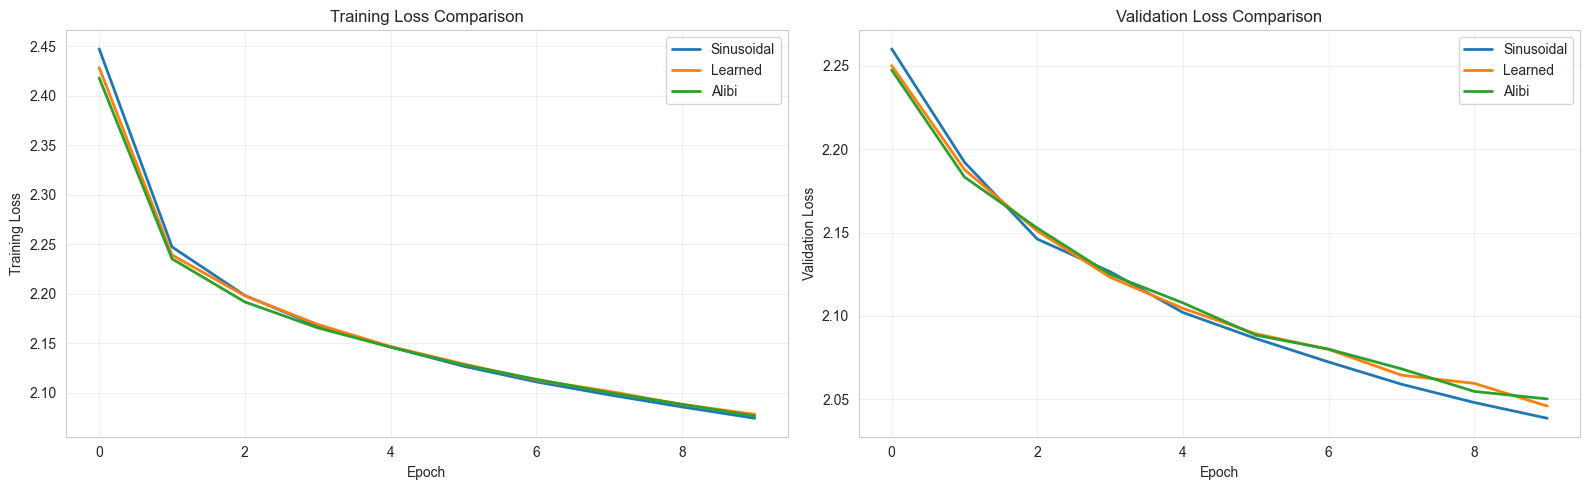


Final Validation Losses:
Sinusoidal  : 2.0388
Learned     : 2.0461
Alibi       : 2.0503


In [24]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training loss
ax = axes[0]
for encoding, history in histories.items():
    ax.plot(history.history['train_loss'], label=encoding.capitalize(), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation loss
ax = axes[1]
for encoding, history in histories.items():
    ax.plot(history.history['val_loss'], label=encoding.capitalize(), linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final losses
print("\nFinal Validation Losses:")
for encoding, history in histories.items():
    print(f"{encoding.capitalize():12s}: {history.history['val_loss'][-1]:.4f}")

### Key Takeaways: Which Encoding to Use?

Based on our experiments and the literature:

**Sinusoidal** (Original Transformer):
- ✅ No parameters, works out of the box
- ✅ Good relative position properties
- ❌ Not task-specific
- **Use when**: You want simplicity and good generalization

**Learned** (GPT, BERT):
- ✅ Task-specific, can adapt to data patterns
- ✅ Simple to implement
- ❌ Fixed maximum length
- ❌ Extra parameters
- **Use when**: You have a fixed sequence length and want maximum flexibility

**RoPE** (LLaMA, GPT-NeoX):
- ✅ Excellent length extrapolation
- ✅ Relative position through rotation
- ✅ No extra parameters
- ❌ Requires custom attention implementation
- **Use when**: You need to handle varying sequence lengths (especially long contexts)

**ALiBi** (BLOOM, MPT):
- ✅ Simplest approach (just add bias)
- ✅ Best length extrapolation
- ✅ No extra parameters
- ❌ Linear bias might be too simple for some tasks
- **Use when**: You prioritize simplicity and length generalization

## Summary: The Evolution of Positional Encodings

We've explored how transformers learn sequence order:

1. **The Problem**: Self-attention is permutation invariant — it can't see order

2. **Sinusoidal (2017)**: Fixed encodings with wavelength intuition
   - Different frequencies for different dimensions
   - Relative position through linear transformations

3. **Learned (2018)**: Task-specific embeddings
   - Flexible but limited to max length

4. **Relative (2018-2020)**: Bias based on distance
   - Better for sequence tasks
   - T5-style learned biases

5. **RoPE (2021)**: Rotation-based encoding
   - Excellent extrapolation
   - Used in modern LLMs (LLaMA)

6. **ALiBi (2022)**: Linear attention bias
   - Simplest and most effective for length generalization
   - No embeddings needed

**Modern trend**: Moving from absolute → relative → implicit (bias-based) encodings for better generalization.

**For your projects**:
- **Short, fixed length**: Learned embeddings
- **Variable length**: Sinusoidal or ALiBi
- **Long contexts**: RoPE or ALiBi
- **Research/experimentation**: Try all and compare!